# QRE Analysis for Arithmetic Variants

Fault-tolerant quantum algorithm design fundamentally differs from NISQ algorithm design by recognizing that quantum computers need to be capable of performing operations traditionally considered "classical," such as data loading and arithmetic. Although these subroutines do not offer a quantum advantage in isolation, their efficient implementation is essential to realizing speedups across a broad range of applications.

Thus, quantum algorithm developers need to use optimal subroutines for classical operations (e.g., adders). Unfortunately, the ideal implementation of these operations remains an open question, and is an active area of research. In this notebook, we explore quantum resource estimation (QRE) as a tool to guide algorithmic design by examining four distinct adder implementations:

- **NaiveAdd**: A straightforward implementation that iterates through the bits of the input register, using multi-controlled `not` gates to flip the corresponding bits of the target register based on the addend and any carry bits.
- **QFTAdd**: An adder based on the quantum Fourier transform, as detailed in "Quantum arithmetic with the Quantum Fourier Transform" ([arXiv:1411.5949](https://arxiv.org/abs/1411.5949)). As we will see, it is outperformed by all other adders; we include it in the list for historical reasons and as a reminder of the importance of benchmarking! 
- **GidneyAdd**: A T-gate-optimal implementation leveraging temporary AND gates, as described in "Halving the cost of quantum addition" ([arXiv:1709.06648](https://arxiv.org/abs/1709.06648)).
- **CuccaroAdd**: A qubit-optimal implementation leveraging in-place majority calculation, as described in "A new quantum ripple-carry addition circuit" ([arXiv:quant-ph/0410184](https://arxiv.org/abs/quant-ph/0410184)).
  
> Note that the primary focus of this notebook is on QRE rather than the intricate implementation details of the adders—please refer to the [quantum arithmetic tutorial](./Quantum-Arithmetic.ipynb) for a deeper dive into the implementation specifics. For a quick introduction to numerical QREs in Workbench, see the [corresponding tutorial](./Resource-Estimates-Basic-Numerics.ipynb).

## First implementation: Naive Adder

The `NaiveAdd` Qubrick is conceptually simple: it loops through the bits of the addend and uses multi-controlled `not` gates to modify the target register based on the input and carry values. The circuit  below provides clarity—we encourage you to read the circuit carefully as an exercise.

Despite its simplicity, `NaiveAdd` is expensive in terms of QREs. Remember that the QRE cost reported by `resource_estimator` reflects the cost after all gates have been decomposed. You can see this decomposition explicitly by adding the `>>clean-ladder-filter>>` and `>>single-control-filter>>` filters and running the computation again.

{'active_volume': 494,
 'gidney_lelbows': 4,
 'gidney_relbows': 4,
 'measurements': 0,
 'rotations': 0,
 'pprs': 0,
 'ppms': 0,
 't_gates': 0,
 'toffs': 6,
 'qubit_highwater': 8}

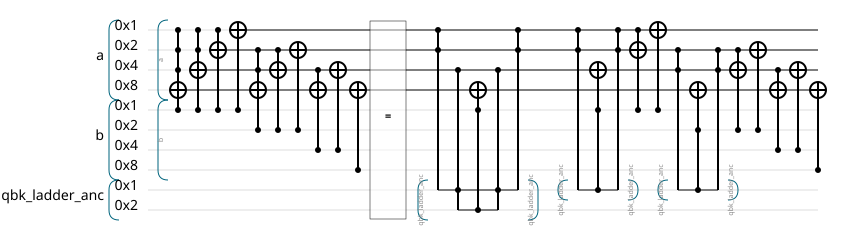

In [1]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.arithmetic import NaiveAdd
from psiqdk.workbench.qre import resource_estimator

qpu = QPU(num_qubits=10)
a = Qubits(4, "a", qpu)
b = Qubits(4, "b", qpu)

# compute the addition
NaiveAdd().compute(a, b)

# display cost of adder
display(resource_estimator(qpu).resources())

# push filter to compare circuit after decomposing long Toffoli gates
qpu.box(" = ")
qpu.push_filter(">>clean-ladder-filter>>")
qpu.push_filter(">>single-control-filter>>")

# compute addition again
NaiveAdd().compute(a, b)

# draw the circuit
qpu.draw()

## Second implementation: QFT Adder

The `QFTAdd` Qubrick is more complex than `NaiveAdd` and employs rotations in the frequency domain to perform addition. [The original paper](https://arxiv.org/abs/1411.5949) offers further details on this approach.

Switching to `QFTAdd` in Workbench requires only a single-line change, although it does necessitate accounting for an extra qubit. 

{'active_volume': 26476.0,
 'gidney_lelbows': 0,
 'gidney_relbows': 0,
 'measurements': 0,
 'rotations': 54,
 'pprs': 0,
 'ppms': 0,
 't_gates': 36,
 'toffs': 0,
 'qubit_highwater': 9}

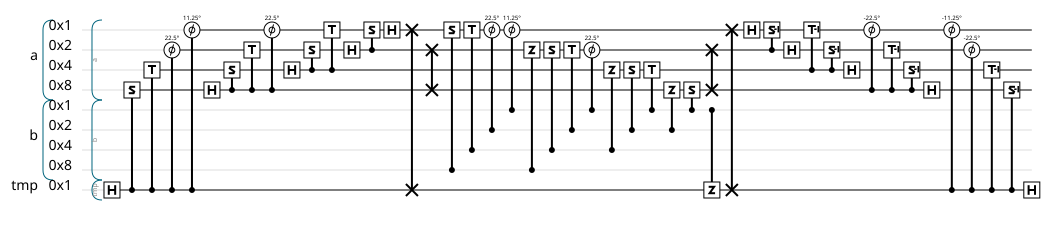

In [2]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.arithmetic import QFTAdd
from psiqdk.workbench.qre import resource_estimator

qpu = QPU(num_qubits=9)
a = Qubits(4, "a", qpu)
b = Qubits(4, "b", qpu)

QFTAdd().compute(a, b)

# check the QREs and display circuit
display(resource_estimator(qpu).resources())
qpu.draw()

Surprisingly, the Toffoli count for `QFTAdd` is 0, yet its active volume is 26476! Compare this to 494 for `NaiveAdd` implementation. This discrepancy arises from the large number of rotations in the circuit. Rotations are extremely costly on fault-tolerant quantum devices because they must be synthesized, typically incurring a high T gate overhead to achieve the required accuracy.

Even though the rotations are not arbitrary (they are reciprocal powers of 2 multiplied by $\pi$), the synthesis cost remains substantial. For `QFTAdd` to be competitive with `NaiveAdd`, the average synthesis cost per rotation would need to be less than one T gate, assuming each Toffoli in `NaiveAdd` costs roughly 4 T gates (and disregarding the cost of Clifford gates).

However, the evaluation of a Qubrick does not hinge solely on gate cost. While `QFTAdd` has a higher gate cost than `NaiveAdd`, it uses asymptotically fewer auxiliary qubits—only a single auxiliary qubit versus $n-2$ for an $n$-bit adder. Although this disparity may be less apparent in small-scale examples, it becomes significant when scaling up. Balancing gate cost against qubit cost remains an open research question, and Workbench is designed as a tool to help explore such trade-offs.

## Third implementation: Gidney Adder

The next implementation examined is the [T-gate-optimal adder](https://arxiv.org/abs/1709.06648), known as Gidney adder. This implementation achieves the lowest known gate cost, though it requires additional auxiliary qubits. Consequently, while `GidneyAdd` offers a 4x reduction in Toffoli count compared to `NaiveAdd`, it incurs extra Clifford costs and uses $n-1$ additional qubits.

{'active_volume': 203,
 'gidney_lelbows': 3,
 'gidney_relbows': 3,
 'measurements': 0,
 'rotations': 0,
 'pprs': 0,
 'ppms': 0,
 't_gates': 0,
 'toffs': 0,
 'qubit_highwater': 11}

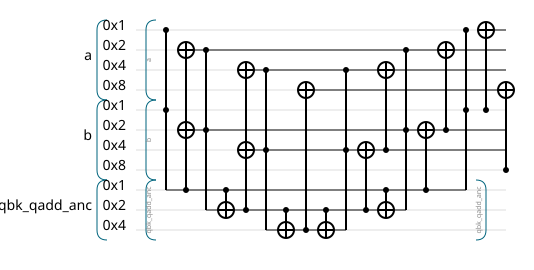

In [3]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.arithmetic import GidneyAdd
from psiqdk.workbench.qre import resource_estimator

qpu = QPU(num_qubits=11)
a = Qubits(4, "a", qpu)
b = Qubits(4, "b", qpu)

GidneyAdd().compute(a, b)

# check the QREs and display circuit
display(resource_estimator(qpu).resources())
qpu.draw()

## Final implementation: Cuccaro Adder

The final implementation examined is the [qubit-optimal adder](https://arxiv.org/abs/quant-ph/0410184), known as Cuccaro adder. While this implementation only utilizes a single auxiliary qubit, the recursive in-place majority requires twice the number of Toffoli gates compared to the out-of-place majority utilized in `GidneyAdd`.

The optimality of an adder ultimately depends on the specific context, requiring programmers to weigh using more qubits against using less T gates. Workbench provides the necessary tools for designing high-performance fault-tolerant quantum algorithms—the ultimate choice of adder implementation should be guided by your particular architectural and algorithmic requirements.

{'active_volume': 338,
 'gidney_lelbows': 0,
 'gidney_relbows': 0,
 'measurements': 0,
 'rotations': 0,
 'pprs': 0,
 'ppms': 0,
 't_gates': 0,
 'toffs': 6,
 'qubit_highwater': 9}

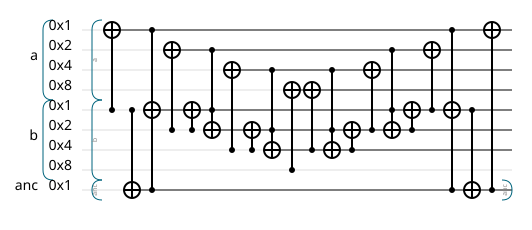

In [4]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.workbench.arithmetic import CuccaroAdd
from psiqdk.workbench.qre import resource_estimator

qpu = QPU(num_qubits=9)
a = Qubits(4, "a", qpu)
b = Qubits(4, "b", qpu)

CuccaroAdd().compute(a, b)

# check the QREs and display circuit
display(resource_estimator(qpu).resources())
qpu.draw()

## Benchmarking
We can visualize the trade-offs in order to choose which implementation to use based on our resource constraints.

> Note that in order to compare the implementations in equivalent forms we first call the `>>clean-ladder-filter>>` to convert all multi-control Toffolis to standard Toffolis and auxiliary qubits and then we call the `>>elbow-reduction-filter>>` to perform any allowed cancellations. 

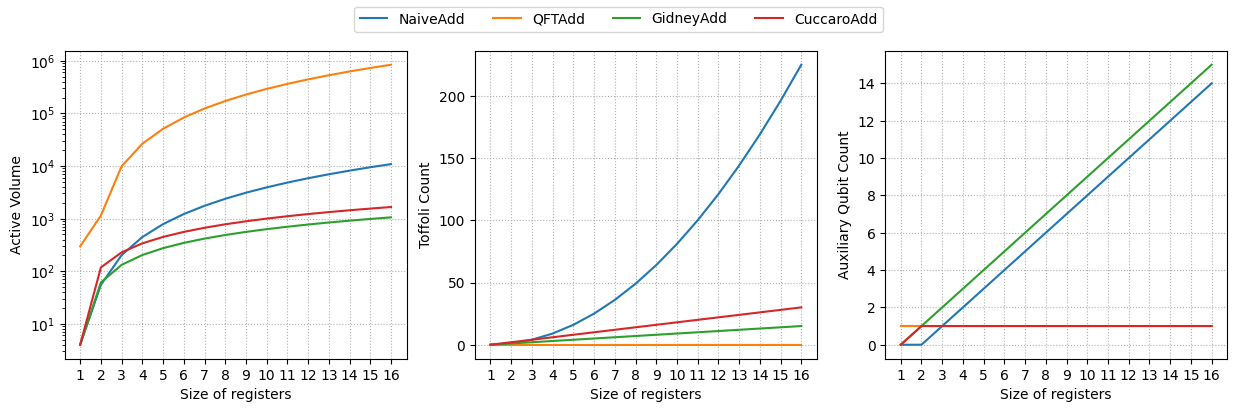

In [5]:
from psiqdk.workbench import QPU, Qubits, Qubrick
from psiqdk.workbench.arithmetic import CuccaroAdd, GidneyAdd, NaiveAdd, QFTAdd
from psiqdk.workbench.qre import resource_estimator
import matplotlib.pyplot as plt

# Benchmark metrics with input size
def fetch_adder_metrics(size_lhs: int, size_rhs: int, total_num_qubits: int, add_qbk: Qubrick):
    qpu = QPU(num_qubits=total_num_qubits, 
              filters=[">>clean-ladder-filter>>", ">>elbow-reduction-filter>>", ">>single-control-filter>>", ">>buffer>>"])
    lhs = Qubits(size_lhs, "lhs", qpu)
    rhs = Qubits(size_rhs, "rhs", qpu)
    add_qbk.compute(lhs, rhs)
    resources = resource_estimator(qpu).resources()
    n_aux = resources["qubit_highwater"] - size_lhs - size_rhs
    # Left Gidney elbows are equivalent to Toffoli gates here
    n_toffs = resources["toffs"] + resources["gidney_lelbows"]
    return resources["active_volume"], n_toffs, n_aux

def fetch_metrics_vs_size_lhs(max_lhs: int, add_qbk: Qubrick):
    av_vals, n_toff_vals, n_aux_vals = [], [], []
    for size_lhs in range(1, max_lhs):
        size_rhs = size_lhs
        total_num_qubits =  3 * size_lhs # worst case
        av, n_toff, n_aux = fetch_adder_metrics(size_lhs, size_rhs, total_num_qubits, add_qbk)
        av_vals.append(av)
        n_toff_vals.append(n_toff)
        n_aux_vals.append(n_aux)
    return av_vals, n_toff_vals, n_aux_vals
        
def do_adder_subplot(ax, naive_data, qft_data, gidney_data, cuccaro_data):
    x_data = [i for i in range(1, len(naive_data)+1)] 
    ax.plot(x_data, naive_data, label="NaiveAdd")
    ax.plot(x_data, qft_data, label="QFTAdd")
    ax.plot(x_data, gidney_data, label="GidneyAdd")
    ax.plot(x_data, cuccaro_data, label="CuccaroAdd")
    ax.set(xticks=x_data)
    ax.grid(linestyle=":")
    ax.set(xlabel="Size of registers")

av_naive, n_toffoli_naive, n_aux_naive = fetch_metrics_vs_size_lhs(max_lhs=17, add_qbk=NaiveAdd())
av_qft, n_toffoli_qft, n_aux_qft = fetch_metrics_vs_size_lhs(max_lhs=17, add_qbk=QFTAdd())
av_gidney, n_toffoli_gidney, n_aux_gidney = fetch_metrics_vs_size_lhs(max_lhs=17, add_qbk=GidneyAdd())
av_cuccaro, n_toffoli_cuccaro, n_aux_cuccaro = fetch_metrics_vs_size_lhs(max_lhs=17, add_qbk=CuccaroAdd())

# benchmark AV, Toffoli count, auxiliary qubit count
fig, axes = plt.subplots(nrows=1, ncols=3 , figsize=(15, 4))
do_adder_subplot(axes[0], av_naive, av_qft, av_gidney, av_cuccaro)
axes[0].set(yscale="log")
axes[0].set(ylabel="Active Volume")
do_adder_subplot(axes[1], n_toffoli_naive, n_toffoli_qft, n_toffoli_gidney, n_toffoli_cuccaro)
axes[1].set(ylabel="Toffoli Count")
do_adder_subplot(axes[2], n_aux_naive, n_aux_qft, n_aux_gidney, n_aux_cuccaro)
axes[2].set(ylabel="Auxiliary Qubit Count")
_ = fig.legend(*axes[2].get_legend_handles_labels(), loc='upper center', ncol=4)

### Note on subtleties 
The above benchmarks are for when the size of the left-hand side (LHS) is equal to the size of the right-hand side (RHS). If we consider the case when the size of the RHS is less than the size of the LHS, we need to pad the RHS to contain the same number of qubits as the LHS. Thus, in this case all implementations except for `QFTAdd` require more than one auxiliary qubit. However, for unsigned values, we know the padded qubits should be initialized as zero states, which means that any gates controlled on the qubits before they are acted on can be safely removed. This creates a more complex trade-off between auxiliary qubit use and active volume between the implementations.  

For example, we can compare `GidneyAdd` and `CuccaroAdd` for adding two unsigned numbers of different size. In this heatmap the color value shows the percentage additional active volume cost for `CuccaroAdd` compared to `GidneyAdd`, while the number written in white on each block is the number of auxiliary qubits saved by `CuccaroAdd` compared to `GidneyAdd`. We see that, as the size of the RHS is decreased relative to the LHS, we save fewer qubits while simultaneously reducing the additional active volume cost.

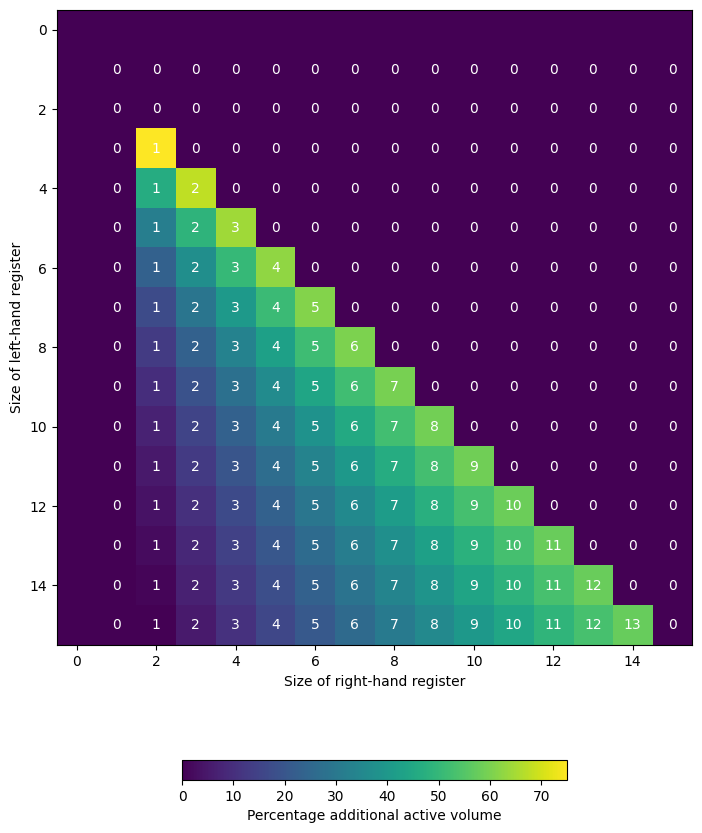

In [6]:
# heatmap for additional AV cost vs qubits saved 
import numpy as np
from psiqdk.workbench.arithmetic import CuccaroAdd, GidneyAdd
import matplotlib.pyplot as plt

N = 16
av_cost = np.zeros((N, N))
aux_saved = np.zeros((N, N))
for i in range(1, N):
    for j in range(1, i):
        avs = []
        auxs = []
        for add_qbk in [GidneyAdd(), CuccaroAdd()]:
            total_num_qubits = 2 * i + 1 if add_qbk == CuccaroAdd() else 2 * i + (i - 1) 
            av, n_toffoli, n_aux = fetch_adder_metrics(i, j, total_num_qubits, add_qbk)
            avs.append(av)
            auxs.append(n_aux)
        av_cost[i][j] = ((avs[1] - avs[0]) / avs[0]) * 100 
        aux_saved[i][j] = auxs[0] - auxs[1]

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(av_cost)
cbar = ax.figure.colorbar(im, ax=ax, orientation="horizontal", fraction=0.025, label="Percentage additional active volume")
for i in range(1, N):
    for j in range(1, N):
        text = ax.text(j, i, int(aux_saved[i, j]),
                       ha="center", va="center", color="w", label="aux saved")    
ax.set_ylabel("Size of left-hand register")
ax.set_xlabel("Size of right-hand register")
plt.show()